In [1]:
# import tree_comparison.tree_compare as tc
# from joblib import Memory
from itertools import combinations
import pandas as pd
import numpy as np
# from utils import *
import utils as u

2026-02-24 23:05:56,567 matplotlib.font_manager INFO     generated new fontManager


In [2]:
morphos, soma_df = u.load_all(axon_radius=0)

In [3]:
# df = soma_df.query("x>10000 and y<5500").set_index("file")
df["id"] = df["file"].map(lambda x: x.split("/")[-1][:-5])
df = soma_df.query("x>9500 and y<6000 and z>2000").set_index("id")
df["z"] = df["zz"]
df.head()

,x,y,z,allenId,sampleNumber,parentNumber,type,zz,subject
file,,,,,,,,,
/data/648434_12_5_24/Complete_annotated/N012-648434-JN.json,9697.7129,4986.8796,4210.2224,146,0,-1,1,4210.2224,648434
/data/648434_12_5_24/Complete_annotated/N022-648434-PG.json,10547.6826,4832.4666,4863.8392,771,0,-1,1,4863.8392,648434
/data/648434_12_5_24/Complete_annotated/N026-648434-PG.json,9805.1909,5907.0996,4330.8163,658,0,-1,1,4330.8163,648434
/data/648434_12_5_24/Complete_annotated/N023-648434-HD.json,10728.7251,4441.3044,4679.5984,771,0,-1,1,4679.5984,648434
/data/648434_12_5_24/Complete_annotated/N020-648434-SS.json,10184.9323,4583.9386,4759.3966,771,0,-1,1,4759.3966,648434


In [4]:
# missing one axon?
df.shape

(131, 9)

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.cm as cm

rand = np.random.default_rng(seed=42)
order = rand.permutation(df.index)

cmap = plt.get_cmap('viridis')
sm = cm.ScalarMappable(cmap=cmap)
data = df.loc[order,"y"]
sm.set_array(data)
clim = np.percentile(data, [5,95])
sm.set_clim(clim)
colors = sm.to_rgba(data)


print(f"{clim=}")

clim=array([4089.4881395, 4977.48005  ])


In [23]:
from importlib import reload
reload(u)

<module 'utils' from '/code/utils.py'>

In [6]:
import vedo
# vedo.settings.default_backend= '2d'
vedo.settings.default_backend= 'k3d'
from vedo.file_io import load_obj


# 
# Load mesh
lc_mesh = load_obj('/root/capsule/data/LC_percentile_meshes/new_core_mesh.obj')[0]
# lc_mesh = load_obj('/root/capsule/data/lc_meshes/20250418_transformed_remesh_10.obj')

In [9]:
# Sagittal view (A-P vs D-V)
def plot_projection(ids, axes, ax, node_types=None, mesh=True, somas=True):
    if mesh:
        # proj_ax = next("xyz"[i] for i in range(3) if i not in axes)
        xx = lc_mesh.vertices[:,[1,2,0]]
        ax.scatter(xx[::10,axes[0]], xx[::10,axes[1]], c='gray', s=1, alpha=0.2)
    ax.set_aspect('equal')

    ax.invert_yaxis()
    # ax.set_xticks([])
    # ax.set_yticks([])
    # for spine in ax.spines.values():
    #     spine.set_visible(False)

    x, y = ["xyz"[i] for i in axes]
    for i, file in enumerate(ids):
        m = morphos[file]
        u.plot_morphology_lines(m, ax, x+y, c=colors[i], linewidth=0.5, node_types=node_types)
        # xx = [n[x] for n in m.nodes()]
        # yy = [n[y] for n in m.nodes()]
        # ax.plot(xx, yy, ',', c=colors[i])
        if somas:
            ax.plot(*df.loc[file, [x,y]], "o", markersize=7, markeredgecolor=colors[i], markerfacecolor='none')


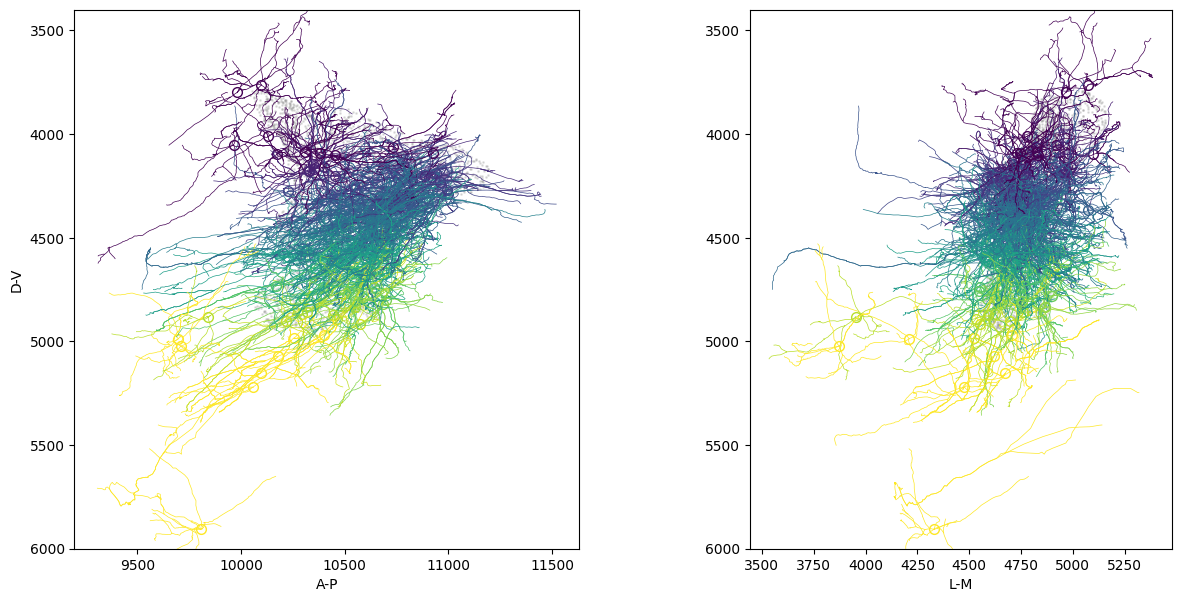

In [10]:
# dendrites
fig, (ax1, ax2) = plt.subplots(
    1, 2,figsize=(15, 7),
)
node_types=[u.BASAL_DENDRITE]
ids = order[:]
plot_projection(ids, [0,1], ax1, node_types=node_types)
ylim=[6000, 3400]
ax1.set_ylim(ylim)
ax1.set_ylabel("D-V")
ax1.set_xlabel("A-P")
plot_projection(ids, [2,1], ax2, node_types=node_types)
ax2.set_ylim(ylim)
ax2.set_xlabel("L-M")

fig.savefig("/scratch/dendrites_dv_colors.pdf")
# fig.savefig("/scratch/dendrites_dv_colors.svg")

In [ ]:
morphos, soma_df = u.load_all(axon_radius=1e9)

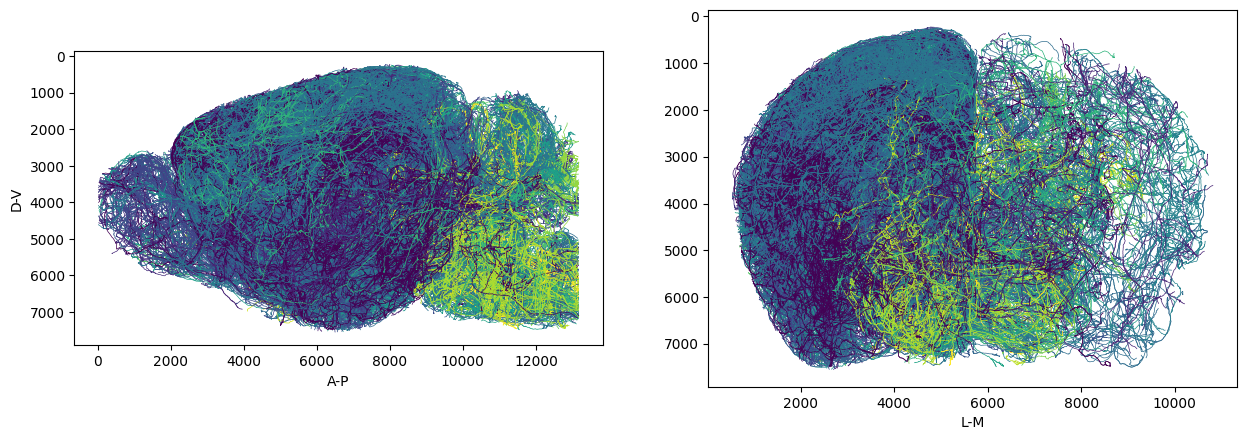

In [41]:
# full axons
fig, (ax1, ax2) = plt.subplots(
    1, 2,figsize=(15, 7),
)
node_types=[ u.AXON]
ids = order[:]
plot_projection(ids, [0,1], ax1, node_types=node_types, mesh=False, somas=False)
ylim=[6000, 3400]
# ax1.set_ylim(ylim)
ax1.set_ylabel("D-V")
ax1.set_xlabel("A-P")
plot_projection(ids, [2,1], ax2, node_types=node_types, mesh=False, somas=False)
# ax2.set_ylim(ylim)
ax2.set_xlabel("L-M")

fig.savefig("/scratch/axons_dv_colors.pdf")
# fig.savefig("/scratch/axons_dv_colors.svg")

Text(0.5, 0, 'L-R')

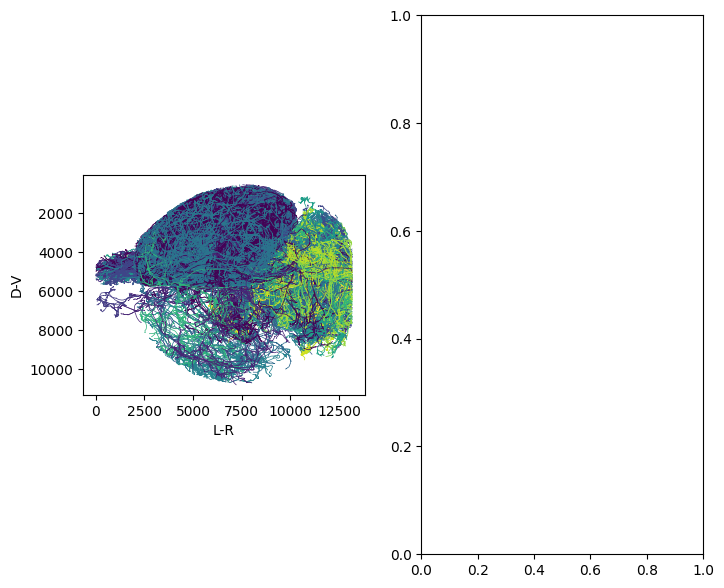

In [46]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,figsize=(8, 7),
)
node_types=[ u.AXON]
ids = order[:]
plot_projection(ids, [0,2], ax1, node_types=node_types, mesh=False, somas=False)
ax1.set_ylabel("D-V")
ax1.set_xlabel("L-R")

In [47]:
fig.savefig("/scratch/axons_dv_colors_horizontal.pdf")

Text(0.5, 0, 'L-M')

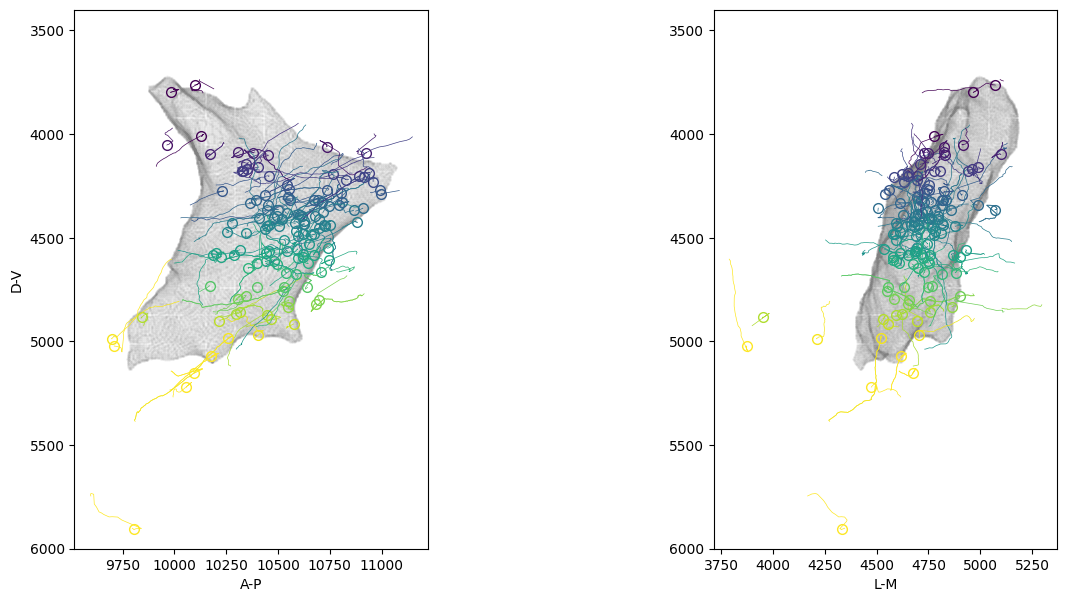

In [ ]:
# proximal axons
fig, (ax1, ax2) = plt.subplots(
    1, 2,figsize=(15, 7),
)
node_types=[ u.AXON]
plot_projection([0,1], ax1, node_types=node_types)
ylim=[6000, 3400]
ax1.set_ylim(ylim)
ax1.set_ylabel("D-V")
ax1.set_xlabel("A-P")
plot_projection([2,1], ax2, node_types=node_types)
ax2.set_ylim(ylim)
ax2.set_xlabel("L-M")

# fig.savefig("/scratch/axons_dv_colors.pdf")
# fig.savefig("/scratch/axons_dv_colors.svg")

In [56]:
# m = morphos[df.index[0]]
spacing = [m.get_compartment_length(c) for c in m.get_compartments()]
np.var(spacing)

1079.169452742064

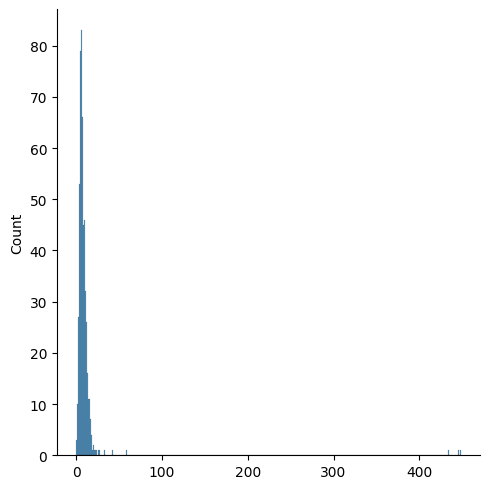

In [57]:
import seaborn as sns
sns.displot(spacing)